# Notebook 5: Final Evaluation

**Notebook Purpose**
This notebook provides the final, unbiased evaluation of the selected model:
1. Load the best model from Notebook 4
2. Load the test set
3. Evaluate model performance on test set
4. Generate predictions vs. actual plots and residual analysis
5. Compare test vs. validation performance
6. Produce report evaluation results and figures

**Key Outputs**
- Final test set performance metrics
- Predictions vs. actual plots
- Residual analysis and error distributions

**Critical Note**
This is the only notebook where test set is accessed. All prior decisions made using validation set. Test performance represents unbiased estimate of model generalization to future data.

## Section 1: Library Imports

In [68]:
import pandas as pd
import pickle
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

**Helper functions**

In [69]:
# Reused from notebook 4
def add_datetime_and_sort(df):
    df = df.copy()
    df["__dt__"] = pd.to_datetime(
        dict(year=df["Year"], month=df["Month"], day=df["Day"]),
        errors='coerce'
    )
    df = df.sort_values("__dt__").reset_index(drop=True)
    return df

## Section 2: Model and Data Ingestion

In [70]:
testing_set_file_path = '../Data/Data Splits/Processed/Testing Set.csv'

testing_df = pd.read_csv(testing_set_file_path)
testing_df.head()

,Latitude,Longitude,Year,Month,Day,chlor_a,poc,sst,Rrs_412,Rrs_443,...,Rrs_667,Rrs_678,sst_anomaly,sst_squared,log_chlor_a,ratio_443_547,sst_chlor_interaction,abs_latitude,season,Oxygen
0,54.4850,12.2783,2015,8,20,6.466959,587.799988,17.264999,0.000658,0.001500,...,0.000948,0.000948,-0.467947,298.080204,1.866706,0.343721,32.228678,54.4850,Summer,278.0
1,53.9435,14.2353,2015,8,20,50.402538,2635.600098,20.879999,-0.000568,0.000556,...,0.003616,0.003424,3.147053,435.974365,3.920042,0.083811,81.850464,53.9435,Summer,271.0
2,53.9640,14.2450,2015,8,20,50.402538,2635.600098,20.879999,-0.000568,0.000556,...,0.003616,0.003424,3.147053,435.974365,3.920042,0.083811,81.850464,53.9640,Summer,284.0
3,54.0060,14.2330,2015,8,20,30.315069,2019.599976,20.650000,-0.000204,0.000878,...,0.002420,0.002180,2.917053,426.422484,3.411645,0.141888,70.450466,54.0060,Summer,292.0
4,54.5940,16.8683,2015,8,20,39.270168,3033.932344,17.080000,-0.001100,-0.000377,...,0.000203,0.000296,-0.652947,291.726397,3.670465,-0.269093,62.691545,54.5940,Summer,284.0


In [71]:
best_model_file_path = '../Results/Model/best_model.pkl'

with open(best_model_file_path, 'rb') as file:
    best_model = pickle.load(file)

In [72]:
testing_df = add_datetime_and_sort(testing_df)
testing_df = testing_df.drop("__dt__", axis=1)
#testing_df.columns
print(sorted(testing_df.columns.tolist()))

['Day', 'Latitude', 'Longitude', 'Month', 'Oxygen', 'Rrs_412', 'Rrs_443', 'Rrs_469', 'Rrs_488', 'Rrs_531', 'Rrs_547', 'Rrs_555', 'Rrs_645', 'Rrs_667', 'Rrs_678', 'Year', 'abs_latitude', 'chlor_a', 'log_chlor_a', 'poc', 'ratio_443_547', 'season', 'sst', 'sst_anomaly', 'sst_chlor_interaction', 'sst_squared']


In [73]:
feature_cols = [
    "Latitude", "Longitude", "Year", "Month", "Day",
    "chlor_a", "poc", "sst",
    "Rrs_412", "Rrs_443", "Rrs_469", "Rrs_488", "Rrs_531",
    "Rrs_547", "Rrs_555", "Rrs_645", "Rrs_667", "Rrs_678",
    "sst_anomaly", "sst_squared",
    "log_chlor_a",
    "ratio_443_547",
    "sst_chlor_interaction", "abs_latitude",
    "season",
]
X_test = testing_df[feature_cols]

testing_df["Pred_DO"] = best_model.predict(X_test)
testing_df["Error_DO"] = testing_df["Pred_DO"] - testing_df["Oxygen"]

In [74]:
testing_df[['Oxygen','Pred_DO','Error_DO']].describe().T

,count,mean,std,min,25%,50%,75%,max
Oxygen,7103.0,264.563081,57.270543,3.000000,219.214600,258.000000,302.000000,400.000000
Pred_DO,7103.0,268.568756,51.707855,93.329567,225.616806,267.910004,304.432281,413.493713
Error_DO,7103.0,4.006240,29.595662,-165.341733,-6.658279,2.056030,13.987061,373.471924


**Section 3: Regression Performance Metrics**

In [75]:
y_true = testing_df["Oxygen"].values
y_pred = testing_df["Pred_DO"].values

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse) #mean_squared_error(y_true, y_pred, squared=False)
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)

print(f"Test RMSE: {rmse:.2f}")
print(f"Test MAE : {mae:.2f}")
print(f"Test R²  : {r2:.3f}")

Test RMSE: 29.86
Test MAE : 18.91
Test R²  : 0.728


In [76]:
## Regression Performance Metrics
model_pred_cols = {
    "BestModel": "Pred_DO"
}

rows = []
for model_name, col in model_pred_cols.items():
    y_hat = testing_df[col].values
    rows.append({
        "Model": model_name,
        "RMSE": np.sqrt( mean_squared_error(y_true, y_hat) ),
        "MAE": mean_absolute_error(y_true, y_hat),
        "R2": r2_score(y_true, y_hat)
    })

metrics_df = pd.DataFrame(rows).sort_values("RMSE")
metrics_df

,Model,RMSE,MAE,R2
0,BestModel,29.863521,18.908363,0.728055


**Section 4: Hypoxia Classification Metrics**

In [77]:
hypoxia_threshold = 60  # Mu mol/kg

#y_true_cls = (testing_df["Pred_DO"] < hypoxia_threshold).astype(int)
#y_true_cls = (testing_df["Oxygen"] < hypoxia_threshold)
#y_pred_cls = (testing_df["Pred_DO"] < hypoxia_threshold)


y_true_cls = (testing_df["Oxygen"] < hypoxia_threshold).astype(int)
y_pred_cls = (testing_df["Pred_DO"] < hypoxia_threshold).astype(int)

precision = precision_score(y_true_cls, y_pred_cls, zero_division=0)
recall    = recall_score(y_true_cls, y_pred_cls, zero_division=0)
f1        = f1_score(y_true_cls, y_pred_cls, zero_division=0)

print(f"Hypoxia classification (DO < {hypoxia_threshold} mu mol/kg):")
print(f"\tPrecision: {precision:.3f}")
print(f"\tRecall   : {recall:.3f}")
print(f"\tF1-score : {f1:.3f}")

cm = confusion_matrix(y_true_cls, y_pred_cls)
cm

Hypoxia classification (DO < 60 mu mol/kg):
	Precision: 0.000
	Recall   : 0.000
	F1-score : 0.000


array([[7091,    0],
       [  12,    0]])

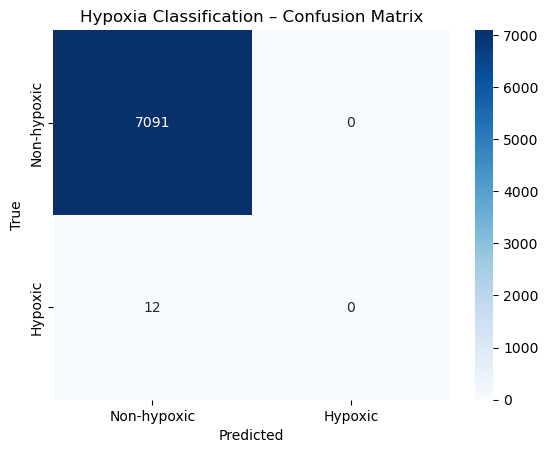

In [78]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-hypoxic", "Hypoxic"],
            yticklabels=["Non-hypoxic", "Hypoxic"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Hypoxia Classification – Confusion Matrix")
plt.savefig('../Results/Figures/confusion_matrix_hypoxia.png', dpi=300, bbox_inches='tight')
plt.show()

**Section 5: Observed vs Predicted Plot**

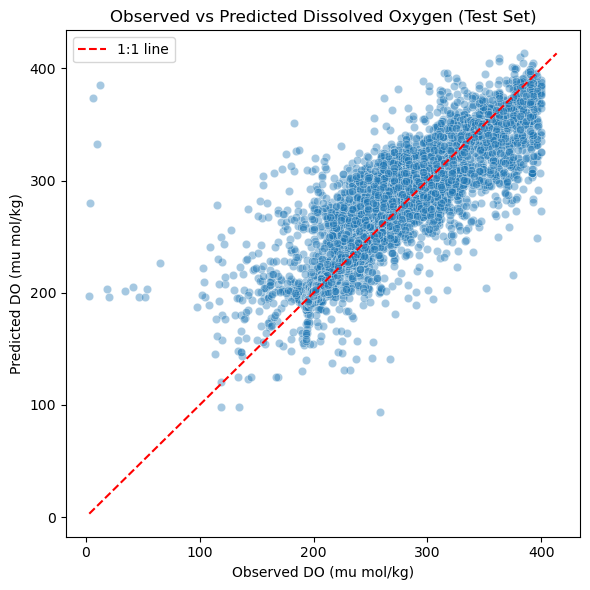

In [79]:
plt.figure(figsize=(6,6))
sns.scatterplot(x="Oxygen", y="Pred_DO", data=testing_df, alpha=0.4)

lims = [min(testing_df["Oxygen"].min(), testing_df["Pred_DO"].min()),
        max(testing_df["Oxygen"].max(), testing_df["Pred_DO"].max())]
plt.plot(lims, lims, "r--", label="1:1 line")

plt.xlabel("Observed DO (mu mol/kg)")
plt.ylabel("Predicted DO (mu mol/kg)")
plt.title("Observed vs Predicted Dissolved Oxygen (Test Set)")
plt.legend()
plt.tight_layout()
plt.savefig('../Results/Figures/observed_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

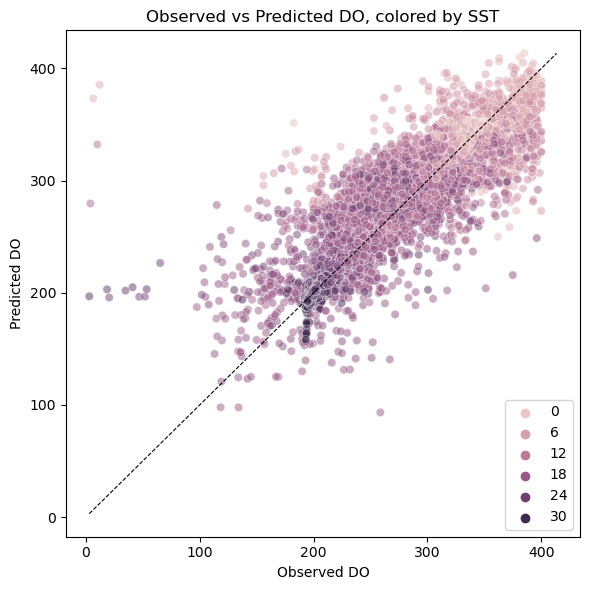

In [80]:
plt.figure(figsize=(6,6))
sns.scatterplot(
    x="Oxygen", y="Pred_DO",
    hue="sst", data=testing_df, alpha=0.5
)
plt.plot(lims, lims, "k--", linewidth=0.8)
plt.xlabel("Observed DO")
plt.ylabel("Predicted DO")
plt.title("Observed vs Predicted DO, colored by SST")
plt.legend()
plt.tight_layout()
plt.savefig('../Results/Figures/observed_vs_predicted_sst.png', dpi=300, bbox_inches='tight')
plt.show()

**Section 6: Error Distribution**

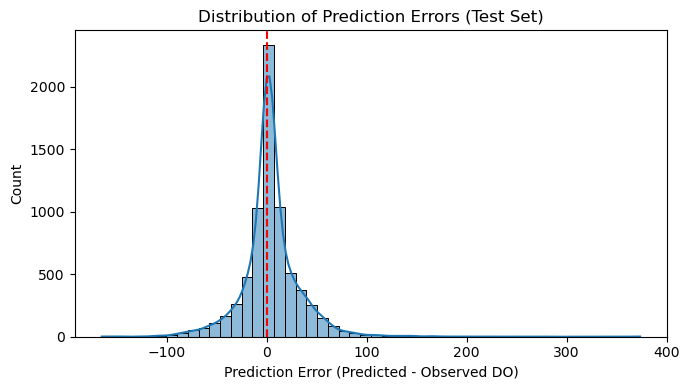

In [81]:
plt.figure(figsize=(7,4))
sns.histplot(testing_df["Error_DO"], bins=50, kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Prediction Error (Predicted - Observed DO)")
plt.ylabel("Count")
plt.title("Distribution of Prediction Errors (Test Set)")
plt.tight_layout()
plt.savefig('../Results/Figures/error_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

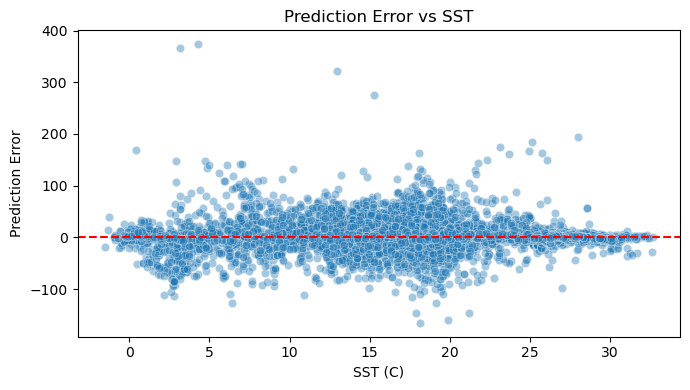

In [82]:
plt.figure(figsize=(7,4))
sns.scatterplot(x="sst", y="Error_DO", data=testing_df, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("SST (C)")
plt.ylabel("Prediction Error")
plt.title("Prediction Error vs SST")
plt.tight_layout()
plt.savefig('../Results/Figures/error_vs_sst.png', dpi=300, bbox_inches='tight')
plt.show()

**Section 7: Spatial Prediction Map**

In [83]:
color_col = "Pred_DO"
vmin = np.nanpercentile(testing_df[color_col], 5)
vmax = np.nanpercentile(testing_df[color_col], 95)

fig = px.scatter_geo(
    testing_df,
    lat="Latitude",
    lon="Longitude",
    color=color_col,
    color_continuous_scale="Turbo",
    range_color=(vmin, vmax),
    opacity=0.7,
    projection="natural earth",
    title="Spatial Prediction Map – Dissolved Oxygen (Predicted, Test Set)",
    hover_data={
        "Pred_DO":  ":.1f",
        "Oxygen":   ":.1f",
        "Error_DO": ":+.1f",
        "sst":      ":.2f" if "sst" in testing_df.columns else False,
        "chlor_a":  ":.3f" if "chlor_a" in testing_df.columns else False,
        "poc":      ":.2f" if "poc" in testing_df.columns else False,
        "Latitude": False,
        "Longitude": False
    }
)

fig.update_traces(marker=dict(size=3, line=dict(width=0.2, color="white")))
fig.update_geos(showland=True, landcolor="lightgray",
                showocean=True, oceancolor="lightblue")

fig.show()

**Section 8: Model Comparison Table**

In [84]:
summary = {
    "Metric": ["RMSE (mu mol/kg)", "MAE (mu mol/kg)", "R2",
               f"Hypoxia Precision (DO<{hypoxia_threshold})",
               f"Hypoxia Recall (DO<{hypoxia_threshold})",
               f"Hypoxia F1 (DO<{hypoxia_threshold})"],
    "Value": [rmse, mae, r2, precision, recall, f1]
}

summary_df = pd.DataFrame(summary)
summary_df

,Metric,Value
0,RMSE (mu mol/kg),29.863521
1,MAE (mu mol/kg),18.908363
2,R2,0.728055
3,Hypoxia Precision (DO<60),0.000000
4,Hypoxia Recall (DO<60),0.000000
5,Hypoxia F1 (DO<60),0.000000
